In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
%%capture
data = ekd.from_source(
    "cds",
    "ecv-for-climate-change",
    request={
        "variable": ["sea_surface_temperature"],
        "origin": ["era5"],
        "product_type": ["anomaly"],
        "climate_reference_period": ["1991_2020"],
        "year": [
            "2014", "2015", "2016",
            "2017", "2018", "2019",
            "2020", "2021", "2022",
            "2023", "2024", "2025",
            "2026"
        ],
        "month": ["08"],
        "time_aggregation": ["1_month_mean"],
        "data_format": "grib",
    },
).to_fieldlist()

In [3]:
data.ls(2)

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,sst,2014-08-01,2014-08-01,0 days,0,surface,0,regular_ll
1,sst,2015-08-01,2015-08-01,0 days,0,surface,0,regular_ll


In [4]:
caption = "Data: Essential climate variables for assessment of climate variability from 1979 to present | DOI: 10.24381/7470b643  | Source: CDS | Created by: Bernadett Piros"

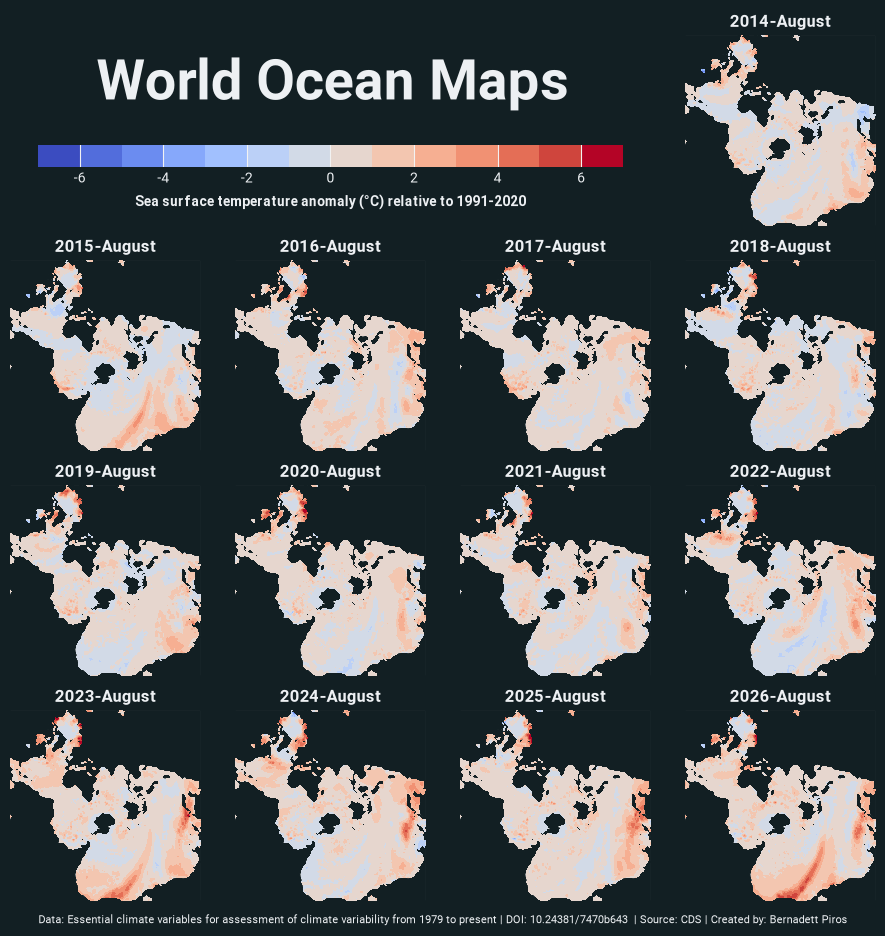

In [5]:
# Dark background
plt.rcParams.update({
    "figure.facecolor": "#121F23",          
})

# Create figure
figure = ekp.Figure(
    figsize=(9, 9),
    rows=4,
    columns=4,
    crs=ccrs.Spilhaus(),
)

# Start at the top-right corner
figure.add_map(0, 3)

for i in range(12):
    figure.add_map(1 + i // 4, i % 4)

# Select sst
sst = data.sel({"parameter.variable": "sst"})

# Add land
figure.land(color="#121F23")

# Plot sst anomalies
figure.contourf(
    sst,
    cmap="coolwarm",
    levels=np.arange(-7, 8, 1),
    transform=ccrs.PlateCarree(),   
)

# Remove subplot frames
for ax in figure.fig.axes:
    for spine in ax.spines.values():
        spine.set_visible(False)

# Inset axis for the colorbar
ax = figure.fig.add_axes((0.05, 0.82, 0.65, 0.025))
cbar = figure.legend(ax=ax, label="{variable_name} anomaly (°C) relative to 1991-2020")[0]

# Colorbar aesthetics
cbar.outline.set_visible(False)
cbar.solids.set_edgecolor("face")
cbar.solids.set_linewidth(0)

# Colorbar labels
cbar.ax.xaxis.label.set_color("#EDF0F3")
cbar.ax.xaxis.label.set_weight("bold")
cbar.ax.tick_params(axis="x", colors="#EDF0F3")

# Add subplot title
figure.subplot_titles(
    "{time.valid_datetime:%Y-%B}",
    color="#EDF0F3",
    fontsize=12,
    weight="bold",
)

# Main title
figure.title(
    "World Ocean Maps",
    fontsize=40,
    color="#EDF0F3",
    fontweight="bold",
    horizontalalignment="left",
    x=0.115,
    y=0.96,
)

# Caption
figure.fig.text(
    0.5,
    -0.02,
    s=caption,
    color="#EDF0F3",
    fontsize=8,    
    ha="center"
)

figure.show()
#figure.save("sst.png", dpi=300)